# A single-band model for La$_{2}$CuO$_{4}$

In this tutorial, we will solve an effective one-band model for La$_{2}$CuO$_{4}$ derived from first-principles within DMFT. Starting from a DFT calculation, we downfolded the full band structure to a minimal correlated subspace using Wannier functions (see [Tutorial 00](00s-dft.ipynb). We include strong local correlations beyond DFT within the single-site dynamical mean-field theory (DMFT) approximation and solve the resulting interacting model self-consistently. While single-site DMFT does not capture all features of cuprate physics (e.g., momentum-dependent self-energies or pseudogap behavior), it provides a foundational framework to understand spectral weight transfer, quasiparticle renormalization, and Mott physics in a realistic setting.

**Specifically, you will learn how to construct and solve the DMFT equations using TRIQS/ModEST.**

## 🧠 DMFT loop from scratch

We will build a single-site DMFT loop for La$_{2}$CuO$_{4}$ using TRIQS/ModEST. Your goal for this tutorial is to fill-in the following Python script:

```python
# total electron density
target_density = 1.0

# define atomic orbtials
shells = 

# create one-body elements from orbitals and TB Hamiltonian (see Exercise 1)
obe = 

# compute the chemical potential (see Exercise 2)
mu = 

# compute the local Green's function (see Exercise 3)
Gloc_C  = 

# define local Green's function for Δ (see Exercise 4)
Gloc    = 
Gloc['up']   << Gloc_C['0','up']
Gloc['down'] << Gloc_C['0','down']

# compute impurity levels (see Exercise 5)
hloc0_C =
hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1)


# compute the hybridization function (see Exercise 5)
Delta_iw =

# write the DMFT loop (see Exercise 8)
for n_iter in range(n_dmft_loops := 5):
    
    # solve!
    solver_results = 

    # update Sigma!
    Sigma_static_C  = 
    
    Sigma_dynamic_C  = 
    Sigma_dynamic_C['0','up'] << solver_results.Sigma_dynamic['up']
    Sigma_dynamic_C['0','down'] <<  solver_results.Sigma_dynamic['down']

    # update mu!
    mu     = 

    # update Gloc!
    Gloc_C  = 
    Gloc['up']   << Gloc_C['0', 'up']
    Gloc['down'] << Gloc_C['0', 'down']

    # update hloc0! εd - μ
    hloc0_C   =
    hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1)

    # update Δ!
    Delta_iw = 

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")
```

**Do not worry we will proceed in stages!**

### 🧪 Exercise 0: Import Python modules

Let's start with importing a few Python modules that we will need for this tutorial. Run the code block below.

In [1]:
import numpy as np

from utils.solvers import solve
from triqs.gf import MeshImFreq, BlockGf
from triqs.operators import n

import triqs_modest as modest

Starting serial run at: 2025-08-05 07:55:17.628199


### 🧪 Exercise 1: Atomic orbitals and one-body elements
We'll start by loading the target electron density and one-body elements (or obe for short) from the Wannier90 data (``lco_tb.dat`` in the ``data/mlwf/`` directory) which can be produced following [Tutorial 1](01s-dft.ipynb). Let's use the function``one_body_elements_from_wanner90`` to construct the ``obe`` object.

> 💡**Tip**: If you want to see the function signature without leaving the notebook to search the API, you can write
> 
> ```
> ?name_of_function
> ```
> 
> This will produce for you a Docstring for the ``name_of_function``

In [2]:
?modest.one_body_elements_from_wannier90

Docstring:
Function dispatched to the following (C++) functions::

   [1] (wannier_file_path: str,
        spin_kind: triqs::modest::spin_kind_e,
        atomic_shells: [AtomicShellT])
     -> OneBodyElements

   [2] (wannier_file_path_up: str,
        wannier_file_path_dn: str,
        spin_kind: triqs::modest::spin_kind_e,
        atomic_shells: [AtomicShellT])
     -> OneBodyElements

.. raw:: html

   <hr>



Construct a obe_tb from Wannier90 in the case of a single spin index

.. raw:: html

   <hr>

**Parameters**
   :wannier_file_path:
      string to Wannier90 files, including the prefix
   :spin_kind:
      enum telling us the spintype
   :shells:
      list of atomic shells input by the user

   .. raw:: html

      <hr>
Type:      builtin_function_or_method

In [3]:
wannier_file_path = "./data/mlwf/lco"
spin_kind         = "NonPolarized"
atomic_orbitals   = [modest.AtomicShellT(dft_idx=0, cls_idx=0, l=2, dim=1)]
obe               = modest.one_body_elements_from_wannier90(wannier_file_path, spin_kind, atomic_orbitals)
print(obe)

triqs_modest.module.OneBodyElements [wrapped from C++ object triqs::modest::one_body_elements]


### 🧪 Exercise 2: Chemical Potential
Let's find the chemical potential the chemical potential that corresponds to our total electron density. You will use the functions ``find_chemical_potential``.

In order to complete this exercise, you will need to define a mesh. We will work at finite-temparature in the imaginary time formalism, so we will work at a system temperature of $T = 1/10$ eV or $\beta = 10$ 1/eV.

In [4]:
opt = modest.BzIntOptions() # k-summation options

beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

target_density = 1.0 # total electron density

mu = modest.find_chemical_potential(target_density, obe, mesh, opt, verbosity=True)

### 🧪 Exercise 3: Compute the Local Green's function
Now that we have the chemical potential, we can compute the non-interacting local Green's function. We will use this define our starting hybridization function $\Delta(i\omega_{n})$.

In [5]:
Gloc_C = modest.gloc(mesh, obe, mu, opt)
print(Gloc_C)

Green's Function  composed of 2 2-index blocks: 
 Greens Function ('0', 'up') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function ('0', 'down') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 4: Reshape the local Green's function for the impurity solvers
The local Green's function we computed above corresponds to a ``Block2Gf``. However, we need to prepare a hybridization function and therefore a Green's function that are ``BlockGf``. For the simple problem, we are currently working on this reshape is trivial. In this exercise, you will make a ``BlockGf`` with block names ``up`` and ``down``.

> 💡 **Tip:** You can make BlockGf from a gf_struct and a mesh. For this problem, ``gf_struct = [('up',1), ('down',1)].``

In [6]:
Gloc = BlockGf(gf_struct=[('up',1), ('down',1)], mesh= mesh)
Gloc['up']   << Gloc_C['0','up']
Gloc['down'] << Gloc_C['0','down']
print(Gloc)

Green Function G composed of 2 blocks: 
 Greens Function G_up with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function G_down with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 5: Impurity Levels and Hybridization function

The central inputs to the impurity solver are the impurity levels ($\varepsilon_{d}$) and the hybridization function ($\Delta(i\omega_{n})$). In this excercise, you will calculate the impurity levels and the hybridization function. The impurity levels correspond to:

$$ [\varepsilon_{d}]_{m m'} = \sum_{k} P_{m\nu}(k) (H_{\nu\nu'}(k)-\mu) P^{\dagger}_{m'\nu'},$$
where $\mu$ is the chemical potential. We can compute the impurity levels with the function ``impurity_levels`` which takes as an argument the ``obe``.

The hybridization function is defined as:

$$ \Delta(\omega) = \omega - \varepsilon_{d} - \mathcal{G}_{0}^{-1}(\omega), $$

where $\mathcal{G}_{0} = ((G_{\text{loc}})^{-1} + \Sigma)^{-1}$. The hybridization function can be computed using the function ``hybridization``.

In [9]:
# Step 1: impurity levels in the C space
hloc0_C = modest.impurity_levels(obe) - mu

# Step 2: reshape the local levels into the impurity space
hloc0 = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1)

# Step 3: compute Δ using mu, hloc0 and Gloc
Delta_iw = modest.hybridization(hloc0, Gloc)

/var/folders/30/m529ltnn38dcg34ksgsm93t80000gn/T/ipykernel_42981/690137374.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hloc0 = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1)


### 🧪 Exercise 6: Plot the DFT local Green's function and Hybridization functions

Before starting the DMFT calculation, let's plot the local Green's function and hybridization functions from DFT.

> 💡**Tip:** Use the ``oplot`` function in ``triqs.plot.mpl_interface`` for quick plotting.

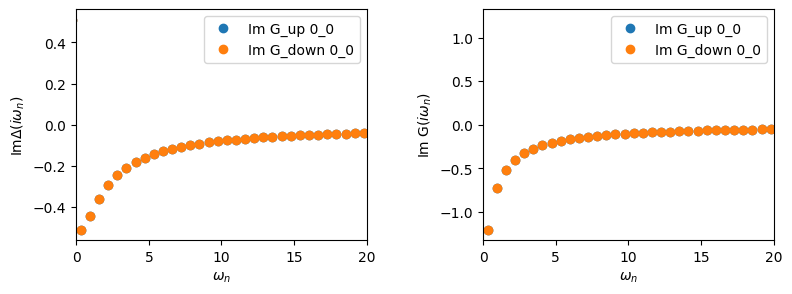

In [10]:
from triqs.plot.mpl_interface import oplot, plt

fig, ax = plt.subplots(1,2, sharex=True, figsize=(9,3))
ax[0].oplot(Delta_iw.imag, 'o'); ax[0].set_ylabel(r'Im$\Delta(i\omega_{n})$')
ax[1].oplot(Gloc.imag, 'o');
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.4)
plt.show()

### 🧪 Exercise 7: Define the interaction
We need to define the interaction Hamiltonian for our impurity model. For our model, this is:

$$ H_{\text{int}} = U n^{\uparrow} n^{\downarrow}.$$

Use the many-body operators within the TRIQS library to write this interaction. Let's take $U$ = 3.6 eV.

> 💡 **Tip**: The many-body operators must match between all of your Green's functions.

In [11]:
U = 3.6
h_int = U*n('up',0)*n('down',0)

### 🧪 Exercise 7: Write the DMFT loop

You now have all of the pieces to write the DMFT self-consistencey loop. Your task is to fill in the steps that occur during each DMFT iteration, such as solving the impurity problem, updating the self-energy, chemical potential, Green's function, and hybridization function.

#### 🧩 Your Task
Fill in the provided pseudocode to perform the following steps for each DMFT iteration:
1. Solve the impurity problem
2. Embed the self-energy
3. Update the chemical potential
4. Compute the local Green's function
5. Update the hybridization function

In [12]:
solver_params = dict(length_cycle=80, n_cycles = int(1e+6), n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=5, fit_max_w=9, imag_threshold = 1e-6)

for n_iter in range(n_dmft_loops := 2):
    
    # solve!
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)

    # update Sigma!
    Sigma_static_C  = np.asarray(solver_results.Sigma_Hartree, dtype=complex).reshape(1,2,1,1)

    Sigma_dynamic_C  = Gloc_C.copy() # BlockGf -> Block2Gf
    Sigma_dynamic_C['0','up']  << solver_results.Sigma_dynamic['up']
    Sigma_dynamic_C['0','down'] << solver_results.Sigma_dynamic['down']

    # update mu!
    mu     = modest.find_chemical_potential(target_density, obe, Sigma_dynamic_C, Sigma_static_C, opt, verbosity=False)

    # update Gloc!
    Gloc_C  = modest.gloc(obe, mu, Sigma_dynamic_C, Sigma_static_C, opt)
    Gloc['up']   << Gloc_C['0','up']
    Gloc['down'] << Gloc_C['0','down']

    # update hloc0! εd - μ
    hloc0_C = modest.impurity_levels(obe) - mu
    hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1) # Block2Matrix -> BlockMatrix

    # update Δ!
    Delta_iw = modest.hybridization(hloc0, Gloc, solver_results.Sigma_dynamic, solver_results.Sigma_Hartree)

    print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

Root finder search of Chemical Potential to obtain Total Density = 1 +/- 1e-05
x=0.5, f(x)= -0.00010357170927586829
x=1, f(x)= -9.163363184484016e-05
x=1.5, f(x)= -8.065006251918236e-05
x=2, f(x)= -7.058168653739216e-05
x=2.5, f(x)= -6.138909136860996e-05
x=3, f(x)= -5.3032769150234554e-05
x=3.5, f(x)= -4.547312020351368e-05
x=4, f(x)= -3.8670456257872826e-05
x=4.5, f(x)= -3.25850039344165e-05
x=5, f(x)= -2.71769084479131e-05
x=5.5, f(x)= -2.2406237355596537e-05
x=6, f(x)= -1.8232984929964164e-05
x=6.5, f(x)= -1.4617075944867771e-05
x=7, f(x)= -1.1518369905192923e-05
x=7.5, f(x)= -8.896665511070505e-06
x=8, f(x)= -6.711705248882687e-06
x=8.5, f(x)= -4.923178493669166e-06
x=9, f(x)= -3.490530532967908e-06
x=9.5, f(x)= -2.34397116781964e-06
x=10, f(x)= 2.918209954181131e-06
x=10.5, f(x)= 0.0006433695650661811
x=11, f(x)= 0.03293133680365075
x=11.5, f(x)= 0.1384524519723683
x=12, f(x)= 0.30567734422417236
x=12.5, f(x)= 0.6409142557628674
x=13, f(x)= 1.1840306695668994
0 < Chemical Potenti

] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.0714285 
Average order                              | 0.0141379 
Average sign                               | 0.0145326 
Density Matrix for local static observable | 0.741985  
G_tau measure                              | 0.0757427 
Total measure time                         | 0.917827  
[Rank 0] Acceptance rate for all moves:
Move set Insert two operators: 0.143952
  Move  Insert Delta_up: 0.144037
  Move  Insert Delta_down: 0.143867
Move set Remove two operators: 0.143944
  Move  Remove Delta_up: 0.143987
  Move  Remove Delta_down: 0.143902
Move set Insert four operators: 0.0287112
  Move  Insert Delta_up_up: 0.0320011
  Move  Insert Delta_up_down: 0.0254557
  Move  Insert Delta_down_up: 0.0253122
  Move  Insert Delta_down_down: 0.0320771
Move set Remove four operators: 0.0287

/var/folders/30/m529ltnn38dcg34ksgsm93t80000gn/T/ipykernel_42981/665110573.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hloc0   = np.asarray(hloc0_C[0],dtype=complex).reshape(2,1,1) # Block2Matrix -> BlockMatrix


### 🧪 Exercise 8: Plot results from your DMFT iteration
Let's plot our results so far after a couple of DMFT iterations. Specifically, let's look at the impurity Green's function and the impurity self-energy. The ``solver_results`` container contains the impurity Green's function (``.G_iw``) and the impurity self-energy (``.Sigma_iw``) as members.

> 💡**Tip:** Try using ``oplot`` again for making quick plots.

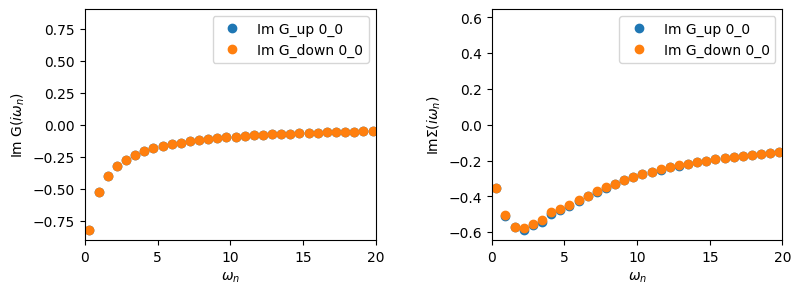

In [13]:
fig, ax = plt.subplots(1,2, sharex=True, figsize=(9,3))
ax[0].oplot(solver_results.G_iw.imag, 'o');     
ax[1].oplot(solver_results.Sigma_iw.imag, 'o'); ax[1].set_ylabel(r'Im$\Sigma(i\omega_{n})$')
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.4)
plt.show()